<a href="https://colab.research.google.com/github/Ajiya-Saleem/PYTHON-CSC262/blob/main/LABTASK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ACTIVITY NO 1**

DFS Traversal Order:
5 3 2 4 8 7 

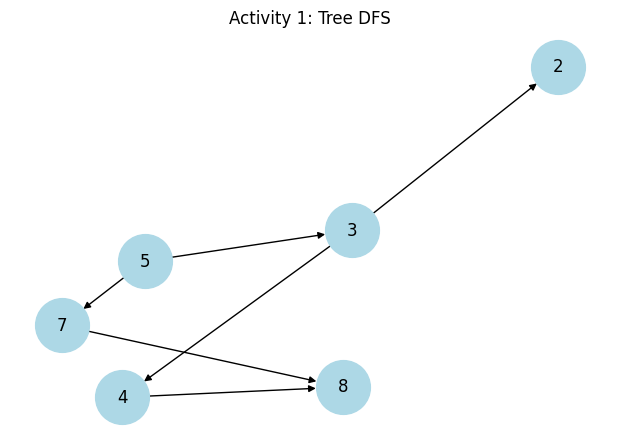

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    '5' : ['3','7'],
    '3' : ['2', '4'],
    '7' : ['8'],
    '2' : [],
    '4' : ['8'],
    '8' : []
}

visited = set()

def dfs(visited, graph, node):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)

print("DFS Traversal Order:")
dfs(visited, graph, '5')

# Visualization
G = nx.DiGraph(graph)
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=1500)
plt.title("Activity 1: Tree DFS")
plt.show()

**ACTIVITY NO 2**

DFS Traversal Order:
0 1 2 3 

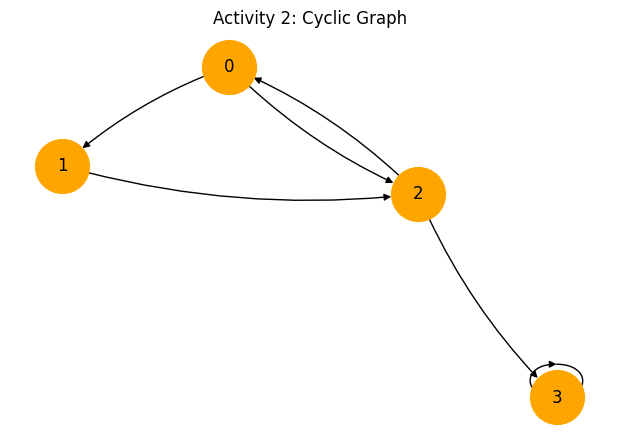

In [8]:
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

class Graph:
    def __init__(self):
        self.graph = defaultdict(list)
    def addEdge(self, u, v):
        self.graph[u].append(v)
    def DFSUtil(self, v, visited):
        visited[v] = True
        print(v, end=" ")
        for i in self.graph[v]:
            if not visited[i]:
                self.DFSUtil(i, visited)
    def DFS(self):
        V = max(self.graph.keys()) + 1
        visited = [False] * V
        for i in range(V):
            if not visited[i]:
                self.DFSUtil(i, visited)

g = Graph()
edges = [(0,1), (0,2), (1,2), (2,0), (2,3), (3,3)]
for u, v in edges: g.addEdge(u, v)

print("DFS Traversal Order:")
g.DFS()

# Visualization
G = nx.DiGraph()
G.add_edges_from(edges)
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_color='orange', node_size=1500, connectionstyle='arc3, rad = 0.1')
plt.title("Activity 2: Cyclic Graph")
plt.show()

**LAB TASK 1**

Path: Arad -> Zerind -> Oradea -> Sibiu -> Fagaras -> Bucharest
Total Distance: 607 km


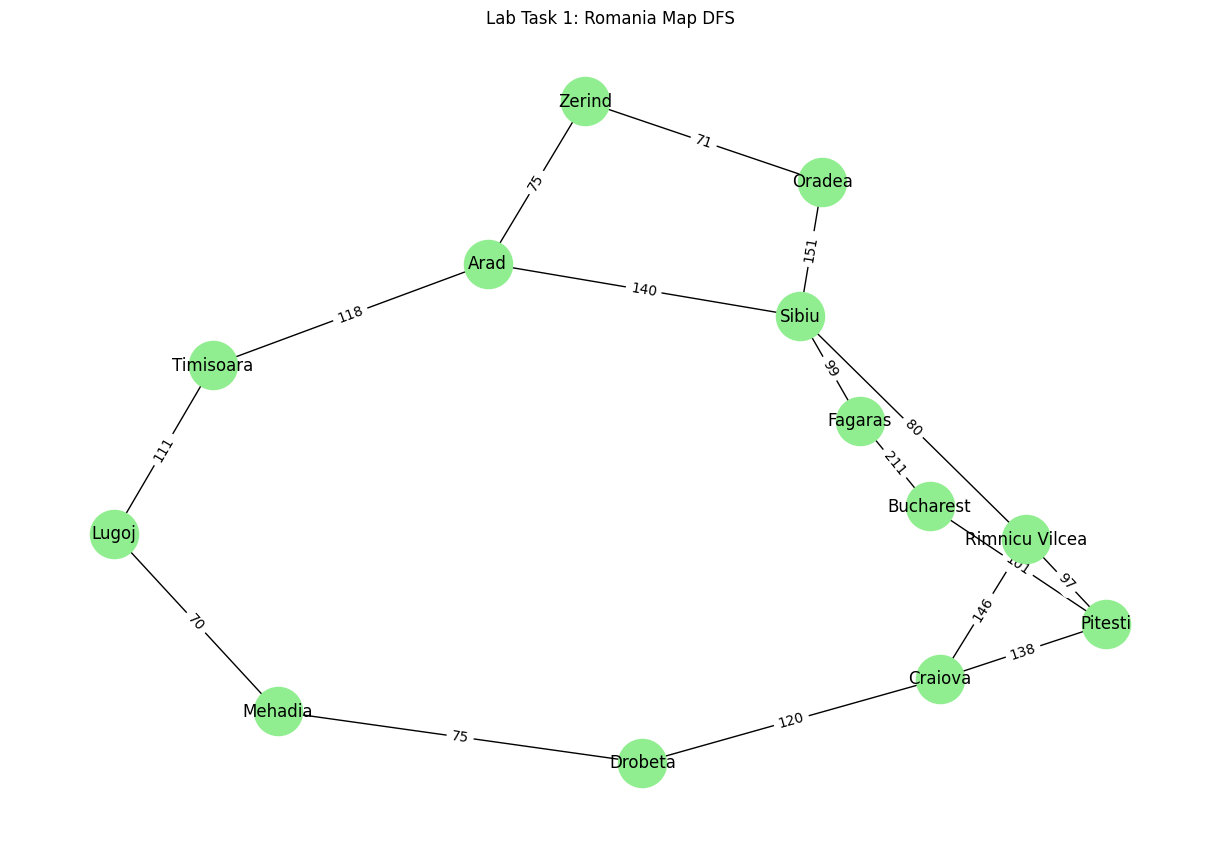

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

romania_map = {
    'Arad': [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)],
    'Zerind': [('Arad', 75), ('Oradea', 71)],
    'Oradea': [('Zerind', 71), ('Sibiu', 151)],
    'Sibiu': [('Arad', 140), ('Oradea', 151), ('Fagaras', 99), ('Rimnicu Vilcea', 80)],
    'Timisoara': [('Arad', 118), ('Lugoj', 111)],
    'Lugoj': [('Timisoara', 111), ('Mehadia', 70)],
    'Mehadia': [('Lugoj', 70), ('Drobeta', 75)],
    'Drobeta': [('Mehadia', 75), ('Craiova', 120)],
    'Craiova': [('Drobeta', 120), ('Rimnicu Vilcea', 146), ('Pitesti', 138)],
    'Rimnicu Vilcea': [('Sibiu', 80), ('Craiova', 146), ('Pitesti', 97)],
    'Fagaras': [('Sibiu', 99), ('Bucharest', 211)],
    'Pitesti': [('Rimnicu Vilcea', 97), ('Craiova', 138), ('Bucharest', 101)],
    'Bucharest': [('Fagaras', 211), ('Pitesti', 101)]
}

def dfs_path(graph, start, goal, visited=None, path=None, dist=0):
    if visited is None: visited = set()
    if path is None: path = []

    path.append(start)
    visited.add(start)

    if start == goal: return path, dist

    for neighbor, weight in graph.get(start, []):
        if neighbor not in visited:
            result_path, result_dist = dfs_path(graph, neighbor, goal, visited, list(path), dist + weight)
            if result_path: return result_path, result_dist
    return None, 0

path, total_dist = dfs_path(romania_map, 'Arad', 'Bucharest')
print(f"Path: {' -> '.join(path)}\nTotal Distance: {total_dist} km")

# Visualization
G = nx.Graph()
for node, neighbors in romania_map.items():
    for neighbor, weight in neighbors:
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1200)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Lab Task 1: Romania Map DFS")
plt.show()

**LAB TASK 2**

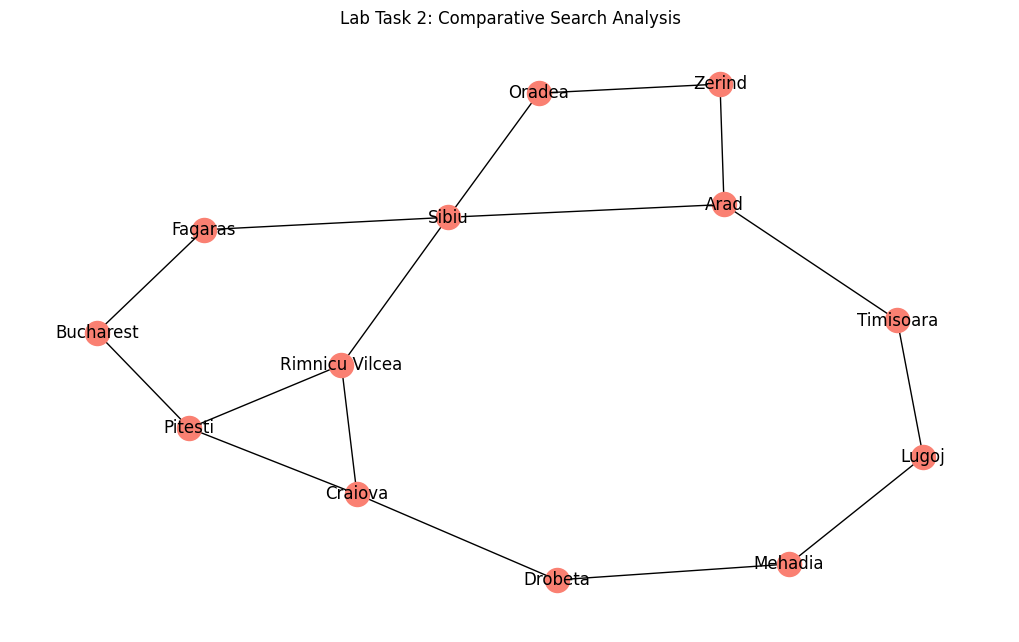

In [10]:
# Use the BFS/DFS comparison code from my previous response here.
# Simply add these visualization lines at the end of that cell:

G_compare = nx.Graph()
# (Assuming romania_map is already defined)
for node, neighbors in romania_map.items():
    for neighbor, weight in neighbors:
        G_compare.add_edge(node, neighbor)

plt.figure(figsize=(10,6))
nx.draw(G_compare, with_labels=True, node_color='salmon')
plt.title("Lab Task 2: Comparative Search Analysis")
plt.show()